# Task 5 – Build and Train MLP & CNN Models
## Plant Disease Classification Project

### Objective:
1. Build and train both MLP and CNN models on PlantVillage dataset.
2. Compare their performance on validation set.
3. Test trained models on random validation samples to compare predicted vs actual labels.

In [13]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,random_split
from torchvision import datasets, transforms
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

## 1. Setup Device
Check if GPU is available.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load Dataset and Split
We use a train/validation split (80/20) from the main dataset folder.

In [14]:
# Dataset path
dataset_path = './dataset/PlantVillage'

# Image transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Load entire dataset
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Train/validation split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Class names
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 15


## 3. Define MLP Model

In [15]:
class SampleNN(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes):
        super(SampleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# MLP parameters
input_size = 3 * 256 * 256  # Flattened image size
hidden_units = 128

# Initialize MLP
mlp_model = SampleNN(input_size=input_size, hidden_units=hidden_units, num_classes=num_classes)
mlp_model.to(device)

# Model summary
summary(mlp_model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1               [-1, 196608]               0
            Linear-2                  [-1, 128]      25,165,952
              ReLU-3                  [-1, 128]               0
            Linear-4                   [-1, 15]           1,935
Total params: 25,167,887
Trainable params: 25,167,887
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.75
Forward/backward pass size (MB): 1.50
Params size (MB): 96.01
Estimated Total Size (MB): 98.26
----------------------------------------------------------------


## 4. Define Simple CNN Model

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*64, 128),  # 256 → 128 after 2x2 pooling twice
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize CNN
cnn_model = SimpleCNN(num_classes=num_classes)
cnn_model.to(device)

# Model summary
summary(cnn_model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
              ReLU-2         [-1, 32, 256, 256]               0
         MaxPool2d-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 64, 128, 128]          18,496
              ReLU-5         [-1, 64, 128, 128]               0
         MaxPool2d-6           [-1, 64, 64, 64]               0
           Flatten-7               [-1, 262144]               0
            Linear-8                  [-1, 128]      33,554,560
              ReLU-9                  [-1, 128]               0
           Linear-10                   [-1, 15]           1,935
Total params: 33,575,887
Trainable params: 33,575,887
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.75
Forward/backward pass size (MB): 56.00
Params size (MB): 128.08
Es

## 5. Define Training & Validation Functions

In [17]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 6. Train MLP Model

In [18]:
num_epochs = 5
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(mlp_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(mlp_model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/5


Validating: 100%|██████████| 129/129 [01:27<00:00,  1.48it/s]


Train Loss: 4.0489, Train Acc: 0.2159
Val Loss: 2.3103, Val Acc: 0.2338

Epoch 2/5


Validating: 100%|██████████| 129/129 [00:23<00:00,  5.46it/s]


Train Loss: 2.3013, Train Acc: 0.2445
Val Loss: 2.2968, Val Acc: 0.2321

Epoch 3/5


...

Train Loss: 2.2770, Train Acc: 0.2457
Val Loss: 2.2422, Val Acc: 0.2461

Epoch 4/5


Validating: 100%|██████████| 129/129 [00:22<00:00,  5.66it/s]


Train Loss: 2.2290, Train Acc: 0.2601
Val Loss: 2.2935, Val Acc: 0.2374

Epoch 5/5


Validating: 100%|██████████| 129/129 [00:22<00:00,  5.64it/s]

Train Loss: 2.2057, Train Acc: 0.2670
Val Loss: 2.1996, Val Acc: 0.2762


## 7. Train CNN Model

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=learning_rate)

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(cnn_model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    


Epoch 1/5


Validating: 100%|██████████| 129/129 [01:23<00:00,  1.54it/s]


Train Loss: 1.2336, Train Acc: 0.6114
Val Loss: 0.7589, Val Acc: 0.7435

Epoch 2/5


Validating: 100%|██████████| 129/129 [01:23<00:00,  1.55it/s]


Train Loss: 0.6523, Train Acc: 0.7843
Val Loss: 0.5812, Val Acc: 0.8096

Epoch 3/5


...

Train Loss: 0.4819, Train Acc: 0.8363
Val Loss: 0.5404, Val Acc: 0.8176

Epoch 4/5


Validating: 100%|██████████| 129/129 [01:31<00:00,  1.42it/s]


Train Loss: 0.3587, Train Acc: 0.8761
Val Loss: 0.5036, Val Acc: 0.8328

Epoch 5/5


Validating: 100%|██████████| 129/129 [01:22<00:00,  1.57it/s]

Train Loss: 0.2490, Train Acc: 0.9149
Val Loss: 0.5228, Val Acc: 0.8372


## 8. Test Model on Random Validation Samples
Compare predicted vs actual labels.

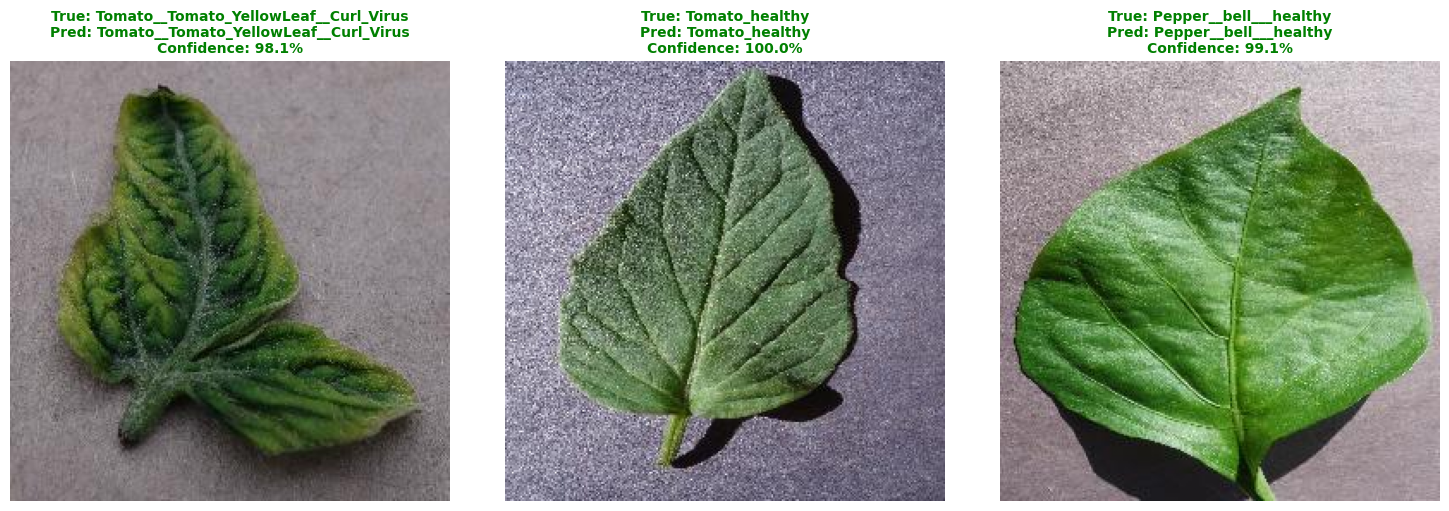

In [20]:
def denormalize(img):
    # For display only if using normalization
    return img

def test_model_on_samples(model, dataset, class_names, num_samples=3, device='cpu'):
    model.eval()
    sample_indices = random.sample(range(len(dataset)), num_samples)
    fig, axes = plt.subplots(1, num_samples, figsize=(5*num_samples, 5))
    if num_samples == 1:
        axes = [axes]
    
    with torch.no_grad():
        for idx, sample_idx in enumerate(sample_indices):
            image, true_label = dataset[sample_idx]
            true_class_name = class_names[true_label]
            
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            probabilities = torch.softmax(output, dim=1)
            pred_prob, pred_label = torch.max(probabilities, 1)
            pred_class_name = class_names[pred_label.item()]
            
            img_display = denormalize(image.clone()).permute(1, 2, 0).cpu().numpy()
            
            color = 'green' if pred_label.item() == true_label else 'red'
            title = f"True: {true_class_name}\nPred: {pred_class_name}\nConfidence: {pred_prob.item()*100:.1f}%"
            
            axes[idx].imshow(img_display)
            axes[idx].axis('off')
            axes[idx].set_title(title, fontsize=10, color=color, weight='bold')
    
    plt.tight_layout()
    plt.show()

# Example usage
test_model_on_samples(cnn_model, val_dataset, class_names, num_samples=3, device=device)
